In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [3]:
titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


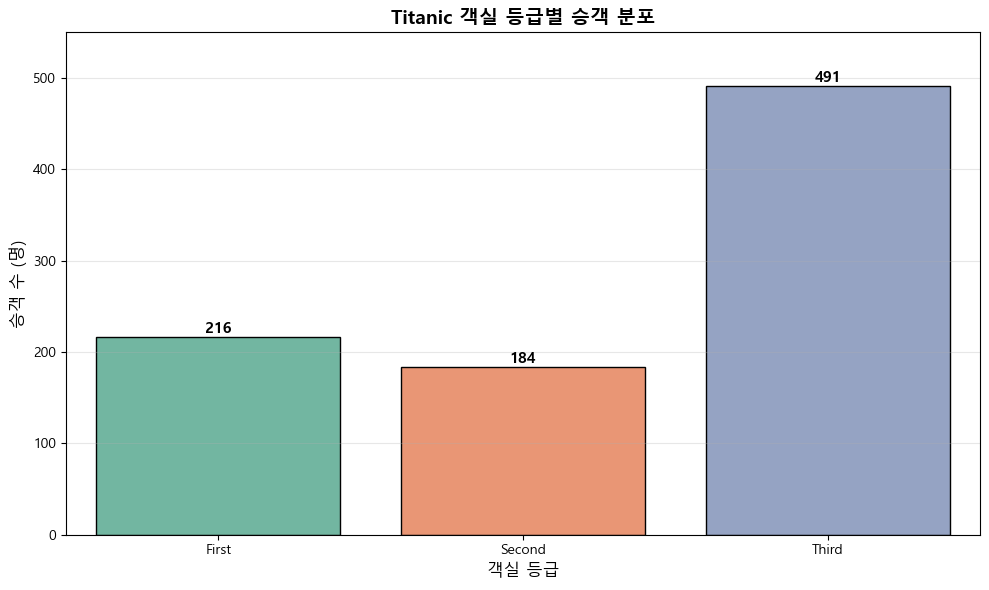

In [4]:
fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(data=titanic,x='class',ax=ax, palette='Set2',edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fontsize=11,fontweight='bold')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('승객 수 (명)', fontsize=12)
ax.set_title('Titanic 객실 등급별 승객 분포', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0,550)
plt.tight_layout()
plt.show()

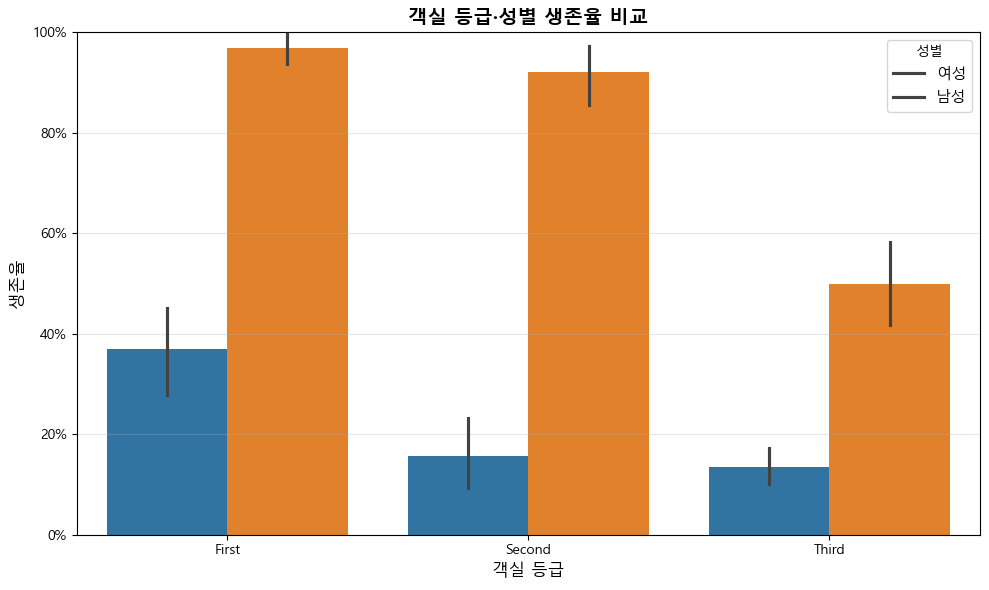

class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


In [5]:
# 성별, 등급별 생존율

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=titanic, x='class', y='survived', hue='sex')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('생존율', fontsize=12)
ax.set_title('객실 등급·성별 생존율 비교', fontsize=14, fontweight='bold')
ax.legend(title='성별', labels=['여성', '남성'], fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

plt.tight_layout()
plt.show()

survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()
print(survival_by_class_sex)

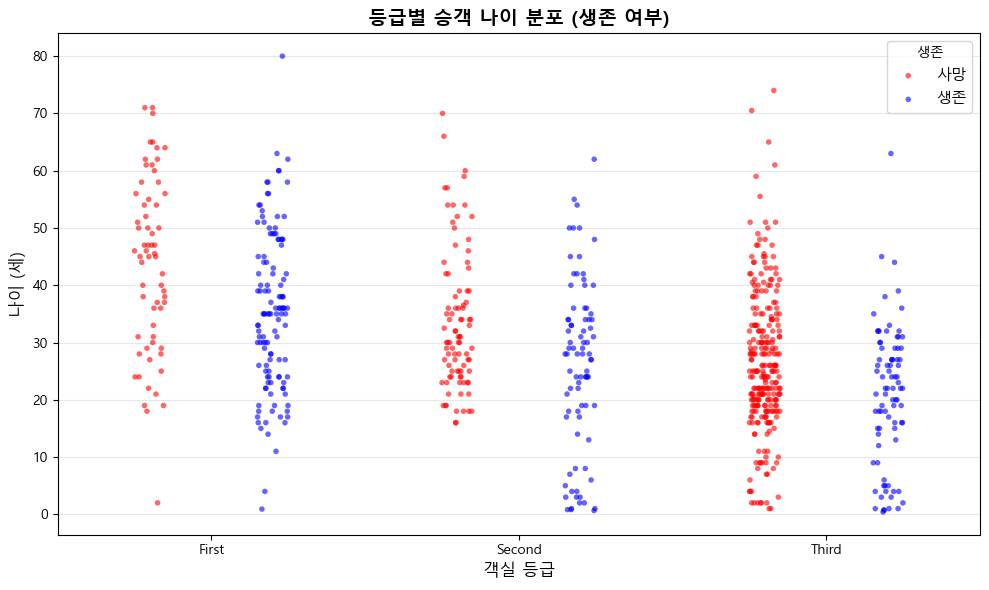

In [6]:
ig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=titanic,x='class',y='age',hue='survived', ax=ax,
              palette={0:'red',1:'blue'}, alpha=0.6, size=4, dodge=True)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('나이 (세)', fontsize=12)
ax.set_title('등급별 승객 나이 분포 (생존 여부)', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


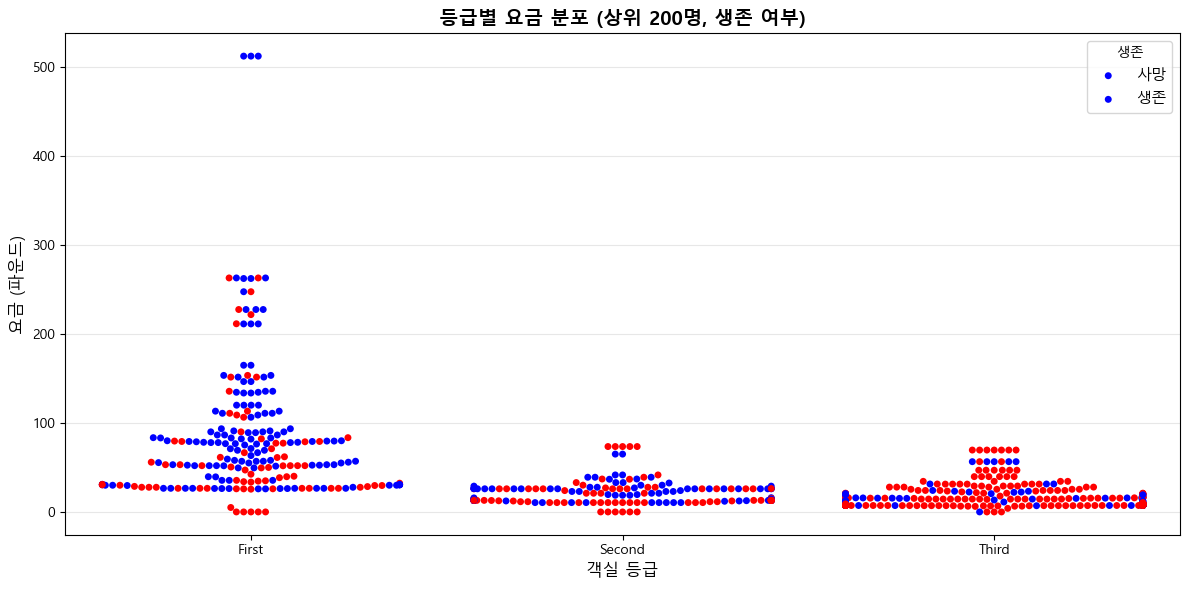

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# 요금 상위 200명만 (가독성 위해)
titanic_fare = titanic.nlargest(200, 'fare')

# Swarmplot 생성
sns.swarmplot(data=titanic, x='class',y='fare',hue='survived', ax=ax,
              edgecolor='black', palette={0:'red',1:'blue'}, size=5)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('요금 (파운드)', fontsize=12)
ax.set_title('등급별 요금 분포 (상위 200명, 생존 여부)', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


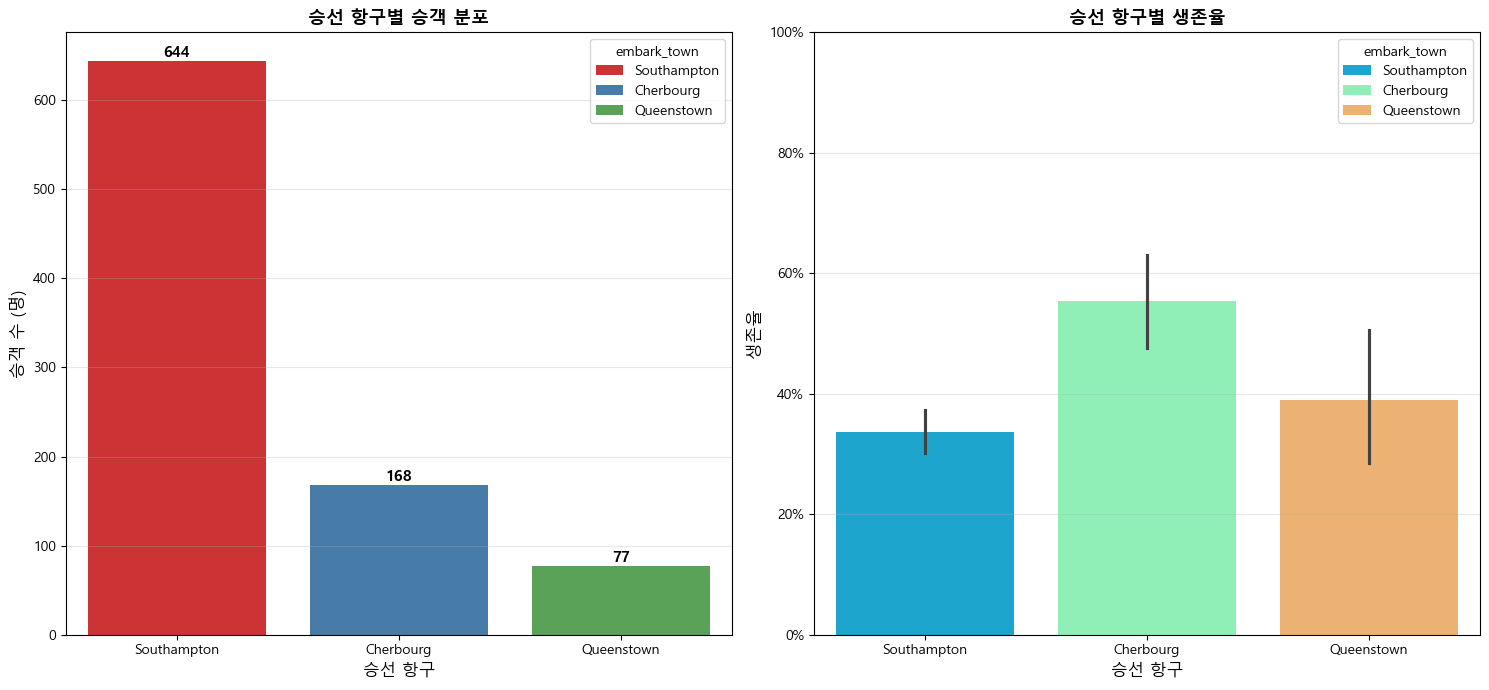

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# 좌측: 항구별 승객 수
sns.countplot(data=titanic, x='embark_town', ax=axes[0], palette='Set1', hue='embark_town')

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold')

axes[0].set_xlabel('승선 항구', fontsize=12)
axes[0].set_ylabel('승객 수 (명)', fontsize=12)
axes[0].set_title('승선 항구별 승객 분포', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 우측: 항구별 생존율
sns.barplot(data=titanic,x='embark_town',y='survived', ax=axes[1], palette='rainbow', hue='embark_town')

axes[1].set_xlabel('승선 항구', fontsize=12)
axes[1].set_ylabel('생존율', fontsize=12)
axes[1].set_title('승선 항구별 생존율', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

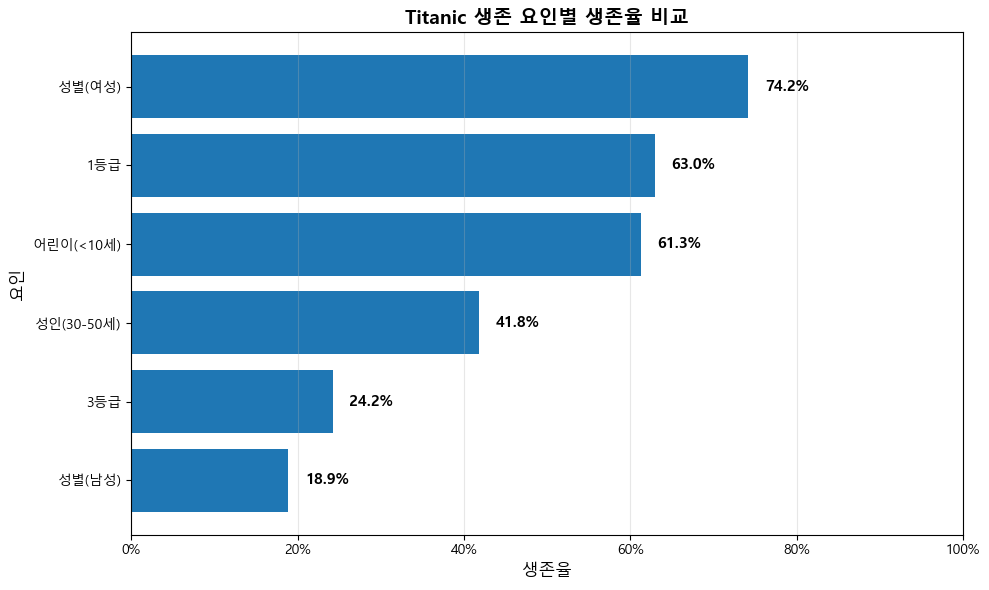

In [25]:
# 각 범주형 변수별 생존율 계산
factors = {
    '성별(여성)': titanic[titanic['sex']=='female']['survived'].mean(),
    '성별(남성)': titanic[titanic['sex']=='male']['survived'].mean(),
    '1등급': titanic[titanic['class']=='First']['survived'].mean(),
    '3등급': titanic[titanic['class']=='Third']['survived'].mean(),
    '어린이(<10세)': titanic[titanic['age']<10]['survived'].mean(),
    '성인(30-50세)': titanic[(titanic['age']>=30) & (titanic['age']<50)]['survived'].mean(),
}

factors_df = pd.DataFrame(list(factors.items()), columns=['요인', '생존율'])
factors_df = factors_df.sort_values('생존율', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(factors_df['요인'], factors_df['생존율'])

# 수치 표시
for i, (factor, rate) in enumerate(zip(factors_df['요인'], factors_df['생존율'])):
    ax.text(rate + 0.02, i, f'{rate*100:.1f}%', 
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('생존율', fontsize=12)
ax.set_ylabel('요인', fontsize=12)
ax.set_title('Titanic 생존 요인별 생존율 비교', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [18]:
factors = {
    '성별(여성)': titanic[titanic['sex']=='female']['survived'].mean(),
    '성별(남성)': titanic[titanic['sex']=='male']['survived'].mean(),
    '1등급': titanic[titanic['class']=='First']['survived'].mean(),
    '3등급': titanic[titanic['class']=='Third']['survived'].mean(),
    '어린이(<10세)': titanic[titanic['age']<10]['survived'].mean(),
    '성인(30-50세)': titanic[(titanic['age']>=30) & (titanic['age']<50)]['survived'].mean(),
    '시니어(60세 이상)': titanic[titanic['age']>=60]['survived'].mean()
}

factors_df = pd.DataFrame(list(factors.items()), columns=['요인', '생존율'])
factors_df = factors_df.sort_values('생존율', ascending=False)
factors_df

,요인,생존율
0,성별(여성),0.742038
2,1등급,0.629630
4,어린이(<10세),0.612903
5,성인(30-50세),0.417969
6,시니어(60세 이상),0.269231
3,3등급,0.242363
1,성별(남성),0.188908
